# Эксперименты

| ступень | что добавляем                                             |
|---|-----------------------------------------------------------|
| 1–3 | Простая сверточная сеть - 2, 4 и 6 свёрточных слоя        |
| 4 | VGG-11                                                    |
| 5 | ResNet-18 не предобученная                                |
| 6 | ResNet-18 предобученная     |
| 7 | ResNet-34         |
| 8 | MobileNet V3 Small  |

Дополнительные две проверки - аугментация и размер входа.

**Условия:**

- одинаковое разделение по людям
- эпохи - 3
- батч - 256
- AdamW с шагом 3e-4

In [18]:
import os
import time
import random
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import kagglehub
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torchvision as tv
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, recall_score, ConfusionMatrixDisplay)

ROOT = Path(kagglehub.dataset_download("akashshingha850/mrl-eye-dataset"))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 3
BATCH = 256

df = pd.read_csv("data/manifest.csv")

TRAIN = df[df.split == "train"]
TEST = df[df.split == "test"]

print("устройство:", DEVICE)
print("обучение:", len(TRAIN), "кадров,", TRAIN.subject.nunique(), "человек")
print("тест:    ", len(TEST), "кадров,", TEST.subject.nunique(), "человек")

устройство: cuda
обучение: 51430 кадров, 22 человек
тест:     16734 кадров, 8 человек


## Подготовка данных и обучение

In [19]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [20]:
class EyeDataset(Dataset):
    def __init__(self, frame, train, aug="full", img=64):
        self.rows = frame.reset_index(drop=True)
        self.train = train
        self.aug = aug
        self.img = img

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows.loc[i]

        img = cv2.resize(
            cv2.imread(
                str(ROOT / r["path"]),
                cv2.IMREAD_GRAYSCALE
            ),
            (self.img, self.img)
        )

        if self.train and self.aug != "none":

            if np.random.rand() < 0.5:
                img = cv2.flip(img, 1)

            if self.aug in ("flip_noise", "full"):
                img = img.astype(np.float32)

                if self.aug == "full":
                    img = 255 * (img / 255.0) ** np.random.uniform(0.5, 2.0)
                    img = img * np.random.uniform(0.7, 1.3) + np.random.uniform(-30, 30)

                if np.random.rand() < 0.7:
                    img = img + np.random.normal(0, np.random.uniform(0, 14), img.shape)
                img = np.clip(img, 0, 255).astype(np.uint8)

                if self.aug == "full" and np.random.rand() < 0.3:
                    img = cv2.GaussianBlur(img, (3, 3), np.random.uniform(0.3, 1.2))

        x = torch.from_numpy(img.astype(np.float32)).div(255).sub(0.5).div(0.5)
        return x.unsqueeze(0), torch.tensor(float(r["label"]))

In [21]:
RESULTS = {}

In [22]:
def train_and_report(name, model, train_df=TRAIN, aug="full", img=64, keep=True):
    gen = torch.Generator().manual_seed(42)

    train_df = DataLoader(EyeDataset(train_df, True, aug, img), batch_size=BATCH,shuffle=True, generator=gen)
    test_df = DataLoader(EyeDataset(TEST, False, img=img), batch_size=512)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
    lossBCE = nn.BCEWithLogitsLoss()

    t0 = time.time()

    for _ in range(EPOCHS):

        model.train()
        for x, y in train_df:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = lossBCE(model(x).squeeze(1), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    minutes = (time.time() - t0) / 60

    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for x, y in test_df:
            p = torch.sigmoid(model(x.to(DEVICE)).squeeze(1))
            probs += p.float().cpu().tolist()
            labels += y.tolist()

    p, l = np.array(probs), np.array(labels)
    pred = (p > 0.5).astype(int)
    acc = float((pred == l).mean())
    auc =  float(roc_auc_score(l, p))

    print(f"=== {name} ===")
    print(f"обучение: {minutes:.1f} мин   вход: {img}×{img}\n")
    print(classification_report(l, pred, target_names=["open", "closed"], digits=4))
    print("ROC-AUC:", round(auc, 4))
    ConfusionMatrixDisplay.from_predictions(l, pred, display_labels=["открыт", "закрыт"],cmap="Blues", values_format=",d", colorbar=False)
    plt.title(name)
    plt.show()

    if keep:
        RESULTS[name] = {"модель": name,
                         "вероятности": p,
                         "истина": l,
                         "точность": acc,
                         "полнота по закрытым": float(recall_score(l, pred)),
                         "ROC-AUC": auc,
                         "минут": minutes}
    return model, acc

## Сверточная сеть - 2 слоя

=== Сверточная сеть - 2 слоя ===
обучение: 1.6 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.4089    0.2445    0.3060      8581
      closed     0.4413    0.6280    0.5183      8153

    accuracy                         0.4313     16734
   macro avg     0.4251    0.4362    0.4122     16734
weighted avg     0.4247    0.4313    0.4095     16734

ROC-AUC: 0.551


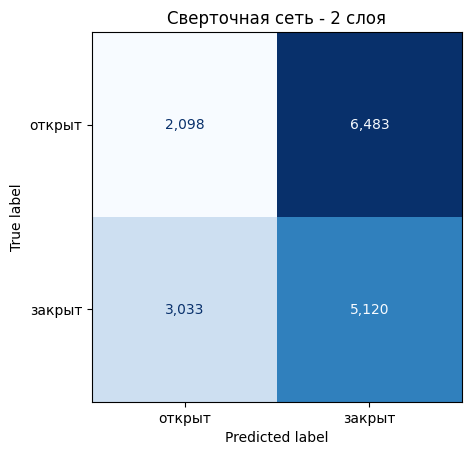

In [17]:
seed_all(42)

model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(32, 1),
)

model, acc = train_and_report("Сверточная сеть - 2 слоя", model)

## Сверточная сеть - 4 слоя

=== Сверточная сеть - 4 слоя ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9005    0.9111    0.9058      8581
      closed     0.9052    0.8940    0.8996      8153

    accuracy                         0.9028     16734
   macro avg     0.9029    0.9026    0.9027     16734
weighted avg     0.9028    0.9028    0.9028     16734

ROC-AUC: 0.9588


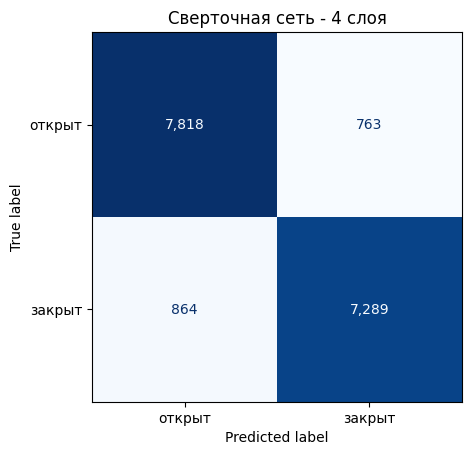

In [23]:
seed_all(42)

model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 1),
)

model, acc = train_and_report("Сверточная сеть - 4 слоя", model)

## Сверточная сеть - 6 слоя

=== Сверточная сеть - 6 слоев ===
обучение: 1.4 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9446    0.9474    0.9460      8581
      closed     0.9445    0.9415    0.9430      8153

    accuracy                         0.9445     16734
   macro avg     0.9445    0.9445    0.9445     16734
weighted avg     0.9445    0.9445    0.9445     16734

ROC-AUC: 0.9878


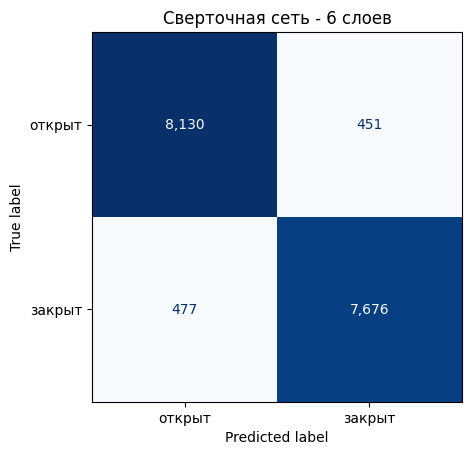

In [24]:
seed_all(42)

model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 1),
)

model, acc = train_and_report("Сверточная сеть - 6 слоев", model)

## VGG-11 предобученная

=== VGG-11 предобученная ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9690    0.9762    0.9726      8581
      closed     0.9748    0.9671    0.9709      8153

    accuracy                         0.9718     16734
   macro avg     0.9719    0.9717    0.9718     16734
weighted avg     0.9718    0.9718    0.9718     16734

ROC-AUC: 0.9964


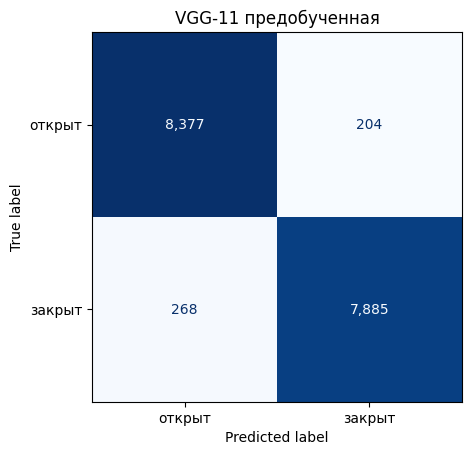

In [25]:
seed_all(42)

model = tv.models.vgg11(weights=tv.models.VGG11_Weights.DEFAULT)

w = model.features[0].weight.data.sum(1, keepdim=True)
model.features[0] = nn.Conv2d(1, 64, kernel_size=3, padding=1)
model.features[0].weight.data = w

model.classifier[6] = nn.Linear(4096, 1)

model, acc = train_and_report("VGG-11 предобученная", model)

## ResNet-18 без предобученных весов

=== ResNet-18 без предобученных весов ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9578    0.9580    0.9579      8581
      closed     0.9558    0.9556    0.9557      8153

    accuracy                         0.9569     16734
   macro avg     0.9568    0.9568    0.9568     16734
weighted avg     0.9569    0.9569    0.9569     16734

ROC-AUC: 0.9903


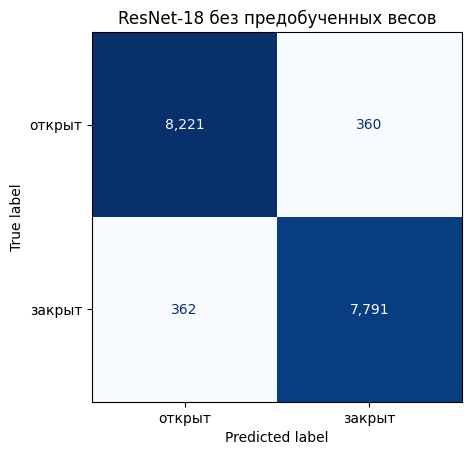

In [26]:
seed_all(42)

model = tv.models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(512, 1)

model, acc = train_and_report("ResNet-18 без предобученных весов", model)

## ResNet-18 предобученная

=== ResNet-18 предобученная ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9786    0.9772    0.9779      8581
      closed     0.9760    0.9776    0.9768      8153

    accuracy                         0.9774     16734
   macro avg     0.9773    0.9774    0.9773     16734
weighted avg     0.9774    0.9774    0.9774     16734

ROC-AUC: 0.9967


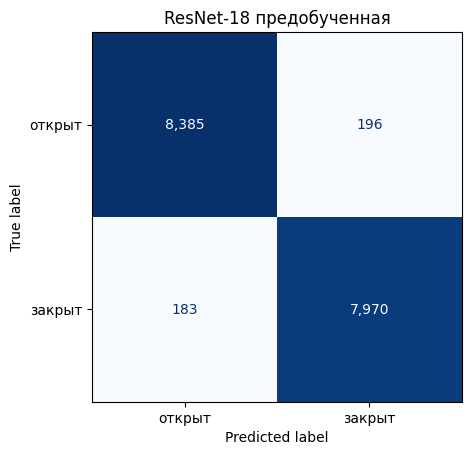

In [27]:
seed_all(42)

model = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)

w = model.conv1.weight.data.sum(1, keepdim=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.conv1.weight.data = w

model.fc = nn.Linear(512, 1)

model, acc = train_and_report("ResNet-18 предобученная", model)

## ResNet-34 предобученная

=== ResNet-34 предобученная ===
обучение: 1.7 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9726    0.9728    0.9727      8581
      closed     0.9714    0.9712    0.9713      8153

    accuracy                         0.9720     16734
   macro avg     0.9720    0.9720    0.9720     16734
weighted avg     0.9720    0.9720    0.9720     16734

ROC-AUC: 0.9969


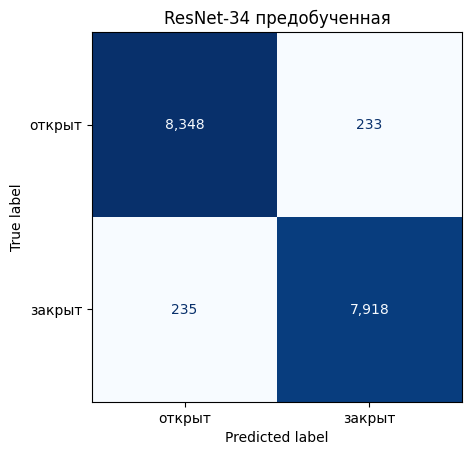

In [28]:
seed_all(42)

model = tv.models.resnet34(weights=tv.models.ResNet34_Weights.DEFAULT)

w = model.conv1.weight.data.sum(1, keepdim=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.conv1.weight.data = w

model.fc = nn.Linear(512, 1)

model, acc = train_and_report("ResNet-34 предобученная", model)

## DenseNet-121 предобученная

=== DenseNet-121 предобученная ===
обучение: 2.2 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9793    0.9821    0.9807      8581
      closed     0.9811    0.9782    0.9796      8153

    accuracy                         0.9802     16734
   macro avg     0.9802    0.9801    0.9801     16734
weighted avg     0.9802    0.9802    0.9802     16734

ROC-AUC: 0.9974


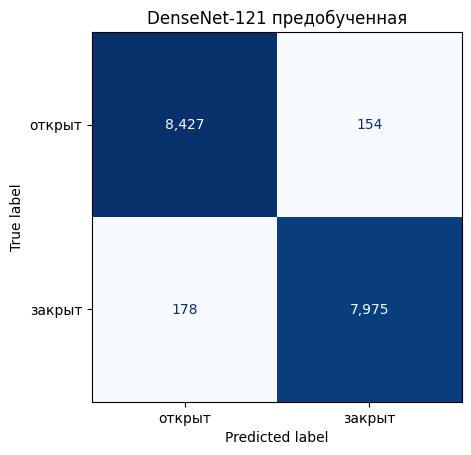

In [29]:
seed_all(42)

model = tv.models.densenet121(weights=tv.models.DenseNet121_Weights.DEFAULT)

w = model.features.conv0.weight.data.sum(1, keepdim=True)
model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.features.conv0.weight.data = w

model.classifier = nn.Linear(1024, 1)

model, acc = train_and_report("DenseNet-121 предобученная", model)

## Итог:

In [30]:
RUNS = list(RESULTS.values())

COLS = ["модель", "точность", "полнота по закрытым", "ROC-AUC", "минут"]

table = pd.DataFrame(RUNS)[COLS]
for c in ("точность", "полнота по закрытым", "ROC-AUC"):
    table[c] = table[c].round(4)
table["минут"] = table["минут"].round(1)

pd.set_option("display.width", 200)
print(table.to_string(index=False))

                           модель  точность  полнота по закрытым  ROC-AUC  минут
         Сверточная сеть - 4 слоя    0.9028               0.8940   0.9588    1.5
        Сверточная сеть - 6 слоев    0.9445               0.9415   0.9878    1.4
             VGG-11 предобученная    0.9718               0.9671   0.9964    1.5
ResNet-18 без предобученных весов    0.9569               0.9556   0.9903    1.5
          ResNet-18 предобученная    0.9774               0.9776   0.9967    1.5
          ResNet-34 предобученная    0.9720               0.9712   0.9969    1.7
       DenseNet-121 предобученная    0.9802               0.9782   0.9974    2.2


## Графики

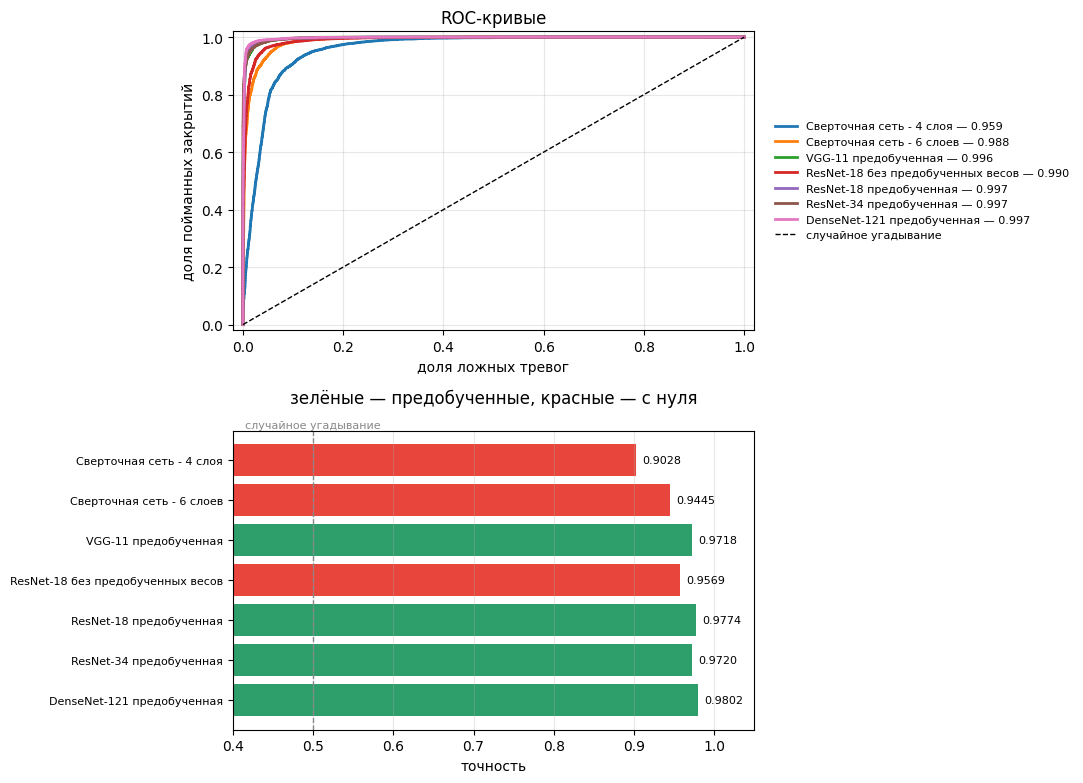

In [31]:
from sklearn.metrics import roc_curve

RUNS = list(RESULTS.values())

n = len(RUNS)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5 + 0.42 * n))

for r in RUNS:
    fpr, tpr, _ = roc_curve(r["истина"], r["вероятности"])
    ax1.plot(fpr, tpr, lw=2, label=f'{r["модель"]} — {r["ROC-AUC"]:.3f}')

ax1.plot([0, 1], [0, 1], "k--", lw=1, label="случайное угадывание")
ax1.set_xlabel("доля ложных тревог")
ax1.set_ylabel("доля пойманных закрытий")
ax1.set_title("ROC-кривые")
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)
ax1.grid(alpha=0.3)


ax1.legend(fontsize=8, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

names = [r["модель"] for r in RUNS]
accs = [r["точность"] for r in RUNS]

def is_pretrained(name):
    return "предобучен" in name and "без" not in name

colors = ["#2E9E6B" if is_pretrained(m) else "#E8453C" for m in names]
pos = list(range(n))

ax2.barh(pos, accs, color=colors)
ax2.set_yticks(pos, names, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlim(0.4, 1.05)
ax2.axvline(0.5, color="#888", lw=1, ls="--")
ax2.text(0.5, 1.01, "случайное угадывание", color="#888", fontsize=8,
         transform=ax2.get_xaxis_transform(), ha="center")
ax2.set_xlabel("точность")
ax2.set_title("зелёные — предобученные, красные — с нуля", pad=20)
ax2.grid(axis="x", alpha=0.3)

for i, a in enumerate(accs):
    ax2.text(a + 0.008, i, f"{a:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Разбор ошибок

In [32]:
best = max(RESULTS.values(), key=lambda r: r["точность"])
print("разбираем:", best["модель"], "— точность", round(best["точность"], 4), "\n")

rows = TEST.reset_index(drop=True).copy()
rows["вероятность"] = best["вероятности"]
assert (rows["label"].to_numpy() == best["истина"]).all(), "порядок кадров разошёлся"

rows["предсказание"] = (rows["вероятность"] > 0.5).astype(int)
rows["верно"] = rows["предсказание"] == rows["label"]

by_subject = rows.groupby("subject").agg(кадров=("верно", "size"),
                                         точность=("верно", "mean"))
by_subject = by_subject.sort_values("точность").round(4)
print(by_subject.to_string())

print(f"\nсреднее по кадрам: {rows['верно'].mean():.4f}")
print(f"среднее по людям:  {by_subject['точность'].mean():.4f}")
print(f"худший человек:    {by_subject['точность'].min():.4f}")
print(f"размах:            {by_subject['точность'].max() - by_subject['точность'].min():.4f}")

разбираем: DenseNet-121 предобученная — точность 0.9802 

         кадров  точность
subject                  
s0030      1384    0.9342
s0018      4410    0.9810
s0031      1738    0.9827
s0036      6193    0.9829
s0034       739    0.9878
s0023       522    0.9885
s0003       679    0.9956
s0004      1069    0.9972

среднее по кадрам: 0.9802
среднее по людям:  0.9812
худший человек:    0.9342
размах:            0.0630


                                          path subject  label  вероятность  glasses  reflections  lighting
  data\test\awake\s0036_05439_1_1_1_0_0_01.png   s0036      0     0.999541        1            0         0
 data\train\awake\s0036_02973_1_0_1_0_0_01.png   s0036      0     0.999439        0            0         0
 data\train\awake\s0036_02984_1_0_1_0_0_01.png   s0036      0     0.999319        0            0         0
   data\val\awake\s0036_02982_1_0_1_0_0_01.png   s0036      0     0.999252        0            0         0
   data\val\awake\s0036_05436_1_1_1_0_0_01.png   s0036      0     0.999114        1            0         0
 data\train\awake\s0036_05432_1_1_1_0_0_01.png   s0036      0     0.999046        1            0         0
 data\test\sleepy\s0031_00052_1_0_0_0_1_02.png   s0031      1     0.001125        0            0         1
data\train\sleepy\s0036_00912_1_1_0_0_0_01.png   s0036      1     0.001129        1            0         0
  data\test\awake\s0036_02981_1_0_1_0

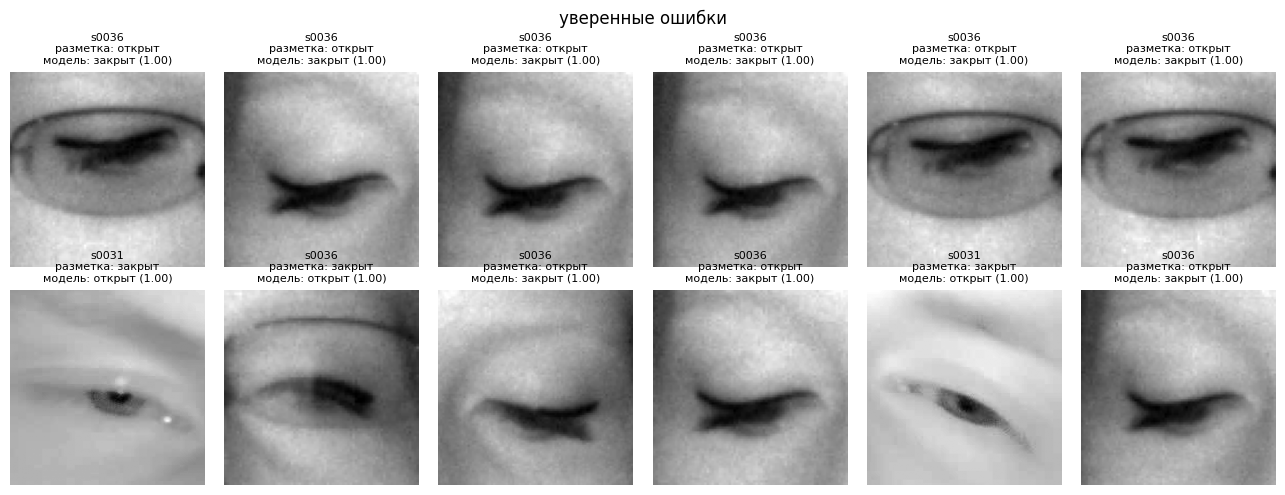

In [33]:
rows["уверенность в ошибке"] = np.where(rows["label"] == 1,
                                        1 - rows["вероятность"],
                                        rows["вероятность"])

worst = rows[~rows["верно"]].nlargest(12, "уверенность в ошибке")
print(worst[["path", "subject", "label", "вероятность",
             "glasses", "reflections", "lighting"]].to_string(index=False))

fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for ax, (_, r) in zip(axes.ravel(), worst.iterrows()):
    ax.imshow(cv2.imread(str(ROOT / r["path"]), cv2.IMREAD_GRAYSCALE), cmap="gray")
    real = "закрыт" if r["label"] == 1 else "открыт"
    said = "закрыт" if r["предсказание"] == 1 else "открыт"
    ax.set_title(f'{r["subject"]}\nразметка: {real}\n'
                 f'модель: {said} ({r["уверенность в ошибке"]:.2f})', fontsize=8)
    ax.axis("off")

plt.suptitle("уверенные ошибки")
plt.tight_layout()
plt.show()

In [34]:
NAMES = {
    "glasses": {0: "без очков", 1: "в очках"},
    "reflections": {0: "без блика", 1: "слабый блик", 2: "сильный блик", 3: "очень сильный"},
    "lighting": {0: "плохой свет", 1: "хороший свет"},
}

for col, names in NAMES.items():
    table = rows.groupby(col)["верно"].agg(кадров="size", точность="mean").round(4)
    table.index = [names.get(v, v) for v in table.index]
    table.index.name = col
    print(table.to_string())
    print()

           кадров  точность
glasses                    
без очков   12119    0.9834
в очках      4615    0.9716

              кадров  точность
reflections                   
без блика      13981    0.9824
слабый блик      806    0.9851
сильный блик    1947    0.9620

              кадров  точность
lighting                      
плохой свет    10563    0.9791
хороший свет    6171    0.9820



## Проверка количества эпох

In [35]:
VAL = df[df.split == "val"]
LONG = 10

seed_all(42)
gen = torch.Generator().manual_seed(42)

train_dl = DataLoader(EyeDataset(TRAIN, True), batch_size=BATCH, shuffle=True, generator=gen)
val_dl = DataLoader(EyeDataset(VAL, False), batch_size=512)
test_dl = DataLoader(EyeDataset(TEST, False), batch_size=512)

model = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)

w = model.conv1.weight.data.sum(1, keepdim=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.conv1.weight.data = w

model.fc = nn.Linear(512, 1)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
lossBCE = nn.BCEWithLogitsLoss()


@torch.no_grad()
def accuracy(loader):
    model.eval()
    ok = 0
    for x, y in loader:
        p = torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu()
        ok += int(((p > 0.5).int() == y.int()).sum())
    return ok / len(loader.dataset)


history = []
print(f"{'эпоха':>6}{'потеря':>10}{'val':>9}{'test':>9}")

for epoch in range(1, LONG + 1):
    model.train()
    total = 0.0
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss = lossBCE(model(x).squeeze(1), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)

    history.append({"эпоха": epoch,
                    "потеря": total / len(train_dl.dataset),
                    "val": accuracy(val_dl),
                    "test": accuracy(test_dl)})

    h = history[-1]
    print(f"{epoch:>6}{h['потеря']:>10.4f}{h['val']:>9.4f}{h['test']:>9.4f}")

top = max(history, key=lambda h: h["val"])
print(f"\nлучшая эпоха по val: {top['эпоха']}  (val {top['val']:.4f}, test {top['test']:.4f})")
print(f"а при наших {EPOCHS} эпохах: test {history[EPOCHS - 1]['test']:.4f}")

 эпоха    потеря      val     test
     1    0.1056   0.9787   0.9711
     2    0.0490   0.9824   0.9699
     3    0.0436   0.9759   0.9774
     4    0.0377   0.9804   0.9746
     5    0.0370   0.9795   0.9745
     6    0.0321   0.9849   0.9747
     7    0.0311   0.9836   0.9728
     8    0.0294   0.9818   0.9725
     9    0.0288   0.9766   0.9725
    10    0.0267   0.9750   0.9721

лучшая эпоха по val: 6  (val 0.9849, test 0.9747)
а при наших 3 эпохах: test 0.9774


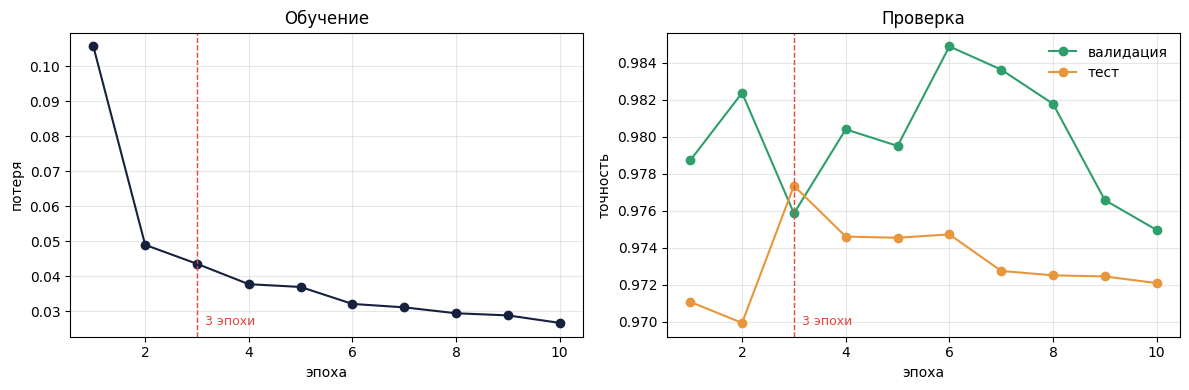

In [36]:
curve = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(curve["эпоха"], curve["потеря"], marker="o", color="#16213E")
ax1.set_xlabel("эпоха")
ax1.set_ylabel("потеря")
ax1.set_title("Обучение")
ax1.grid(alpha=0.3)

ax2.plot(curve["эпоха"], curve["val"], marker="o", color="#2E9E6B", label="валидация")
ax2.plot(curve["эпоха"], curve["test"], marker="o", color="#E8963C", label="тест")
ax2.set_xlabel("эпоха")
ax2.set_ylabel("точность")
ax2.set_title("Проверка")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3)

for ax in (ax1, ax2):
    ax.axvline(EPOCHS, color="#E8453C", lw=1, ls="--")
    ax.text(EPOCHS + 0.15, 0.04, f"{EPOCHS} эпохи", color="#E8453C", fontsize=9,
            transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

## Аугментация

- отражение,
- гамма,
- яркость,
- шум,
- размытие

In [37]:
def damaged(sigma=8, scale=1.0, n=6000, seed=42):
    rng = np.random.default_rng(seed)
    sub = TEST.sample(n, random_state=seed)
    imgs = np.stack([cv2.resize(cv2.imread(str(ROOT / p), cv2.IMREAD_GRAYSCALE), (64, 64)) for p in sub["path"]]).astype(np.float32)
    imgs = np.clip(imgs * scale + rng.normal(0, sigma, imgs.shape), 0, 255)
    x = torch.from_numpy(imgs).float().div(255).sub(0.5).div(0.5).unsqueeze(1)
    return x, sub["label"].to_numpy()

In [38]:
@torch.no_grad()
def score(model, x, y):
    model.eval()
    out = []
    for i in range(0, len(x), 512):
        out.append(torch.sigmoid(model(x[i:i + 512].to(DEVICE)).squeeze(1)).float().cpu())
    return float(((torch.cat(out).numpy() > 0.5).astype(int) == y).mean())


X_noise, Y_noise = damaged(sigma=8)
X_dark, Y_dark = damaged(sigma=3, scale=0.3)

=== аугментация: none ===
обучение: 1.1 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9800    0.9660    0.9729      8581
      closed     0.9647    0.9793    0.9719      8153

    accuracy                         0.9725     16734
   macro avg     0.9724    0.9726    0.9724     16734
weighted avg     0.9726    0.9725    0.9725     16734

ROC-AUC: 0.9963


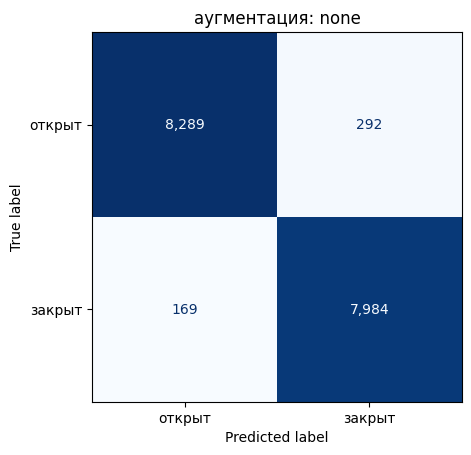


=== аугментация: flip ===
обучение: 1.0 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9756    0.9782    0.9769      8581
      closed     0.9770    0.9742    0.9756      8153

    accuracy                         0.9763     16734
   macro avg     0.9763    0.9762    0.9763     16734
weighted avg     0.9763    0.9763    0.9763     16734

ROC-AUC: 0.997


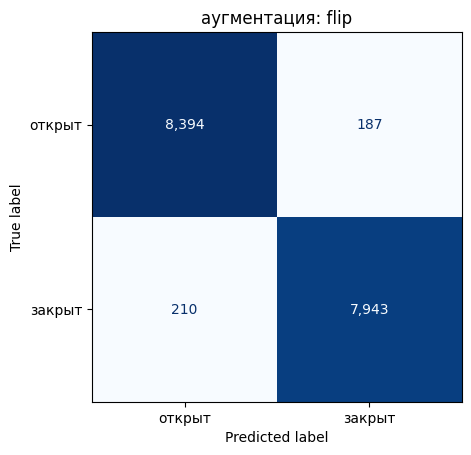


=== аугментация: flip_noise ===
обучение: 1.3 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9744    0.9632    0.9688      8581
      closed     0.9617    0.9734    0.9675      8153

    accuracy                         0.9681     16734
   macro avg     0.9681    0.9683    0.9681     16734
weighted avg     0.9682    0.9681    0.9682     16734

ROC-AUC: 0.9954


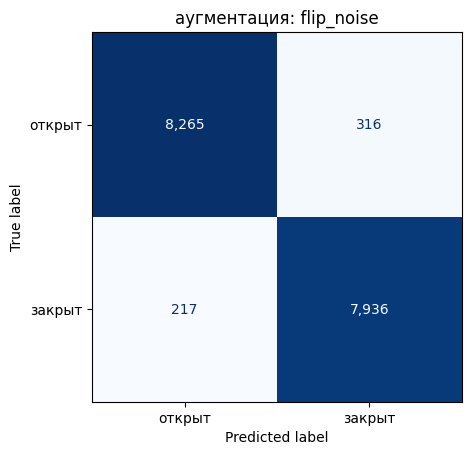


=== аугментация: full ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9786    0.9772    0.9779      8581
      closed     0.9760    0.9776    0.9768      8153

    accuracy                         0.9774     16734
   macro avg     0.9773    0.9774    0.9773     16734
weighted avg     0.9774    0.9774    0.9774     16734

ROC-AUC: 0.9967


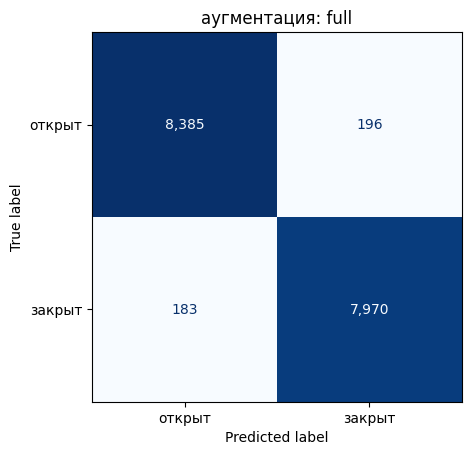


аугментация  чистый тест    шум  темнота
       none       0.9725 0.6355   0.5967
       flip       0.9763 0.5978   0.7487
 flip_noise       0.9681 0.9617   0.8422
       full       0.9774 0.9613   0.9533


In [39]:
rows = []
for aug in ("none", "flip", "flip_noise", "full"):
    seed_all(42)
    model = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)
    w = model.conv1.weight.data.sum(1, keepdim=True)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1.weight.data = w
    model.fc = nn.Linear(512, 1)

    model, acc = train_and_report(f"аугментация: {aug}", model, aug=aug, keep=False)
    rows.append({"аугментация": aug, "чистый тест": round(acc, 4),
                 "шум": round(score(model, X_noise, Y_noise), 4),
                 "темнота": round(score(model, X_dark, Y_dark), 4)})
    print()

print(pd.DataFrame(rows).to_string(index=False))

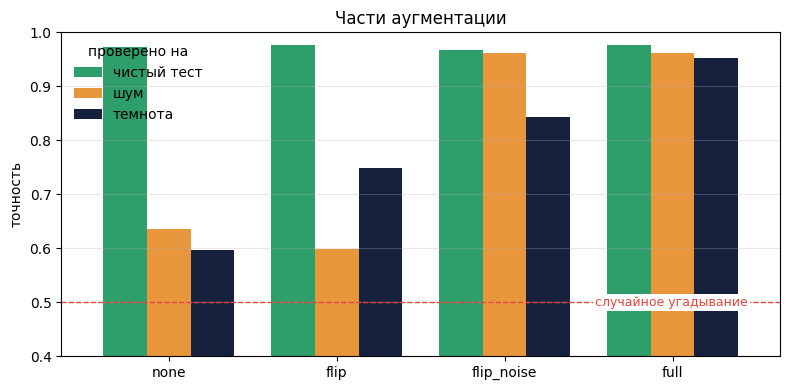

In [40]:
aug_table = pd.DataFrame(rows).set_index("аугментация")
ax = aug_table.plot.bar(figsize=(8, 4), rot=0, width=0.78,
                        color=["#2E9E6B", "#E8963C", "#16213E"])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("точность")
ax.set_xlabel("")
ax.set_title("Части аугментации")
ax.axhline(0.5, color="#E8453C", lw=1, ls="--")
ax.text(3.45, 0.5, "случайное угадывание", color="#E8453C", fontsize=9,
        ha="right", va="center",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
ax.legend(title="проверено на", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Размеры изображения

=== вход 32×32 ===
обучение: 1.3 мин   вход: 32×32

              precision    recall  f1-score   support

        open     0.9730    0.9474    0.9600      8581
      closed     0.9462    0.9723    0.9590      8153

    accuracy                         0.9595     16734
   macro avg     0.9596    0.9599    0.9595     16734
weighted avg     0.9599    0.9595    0.9596     16734

ROC-AUC: 0.9937


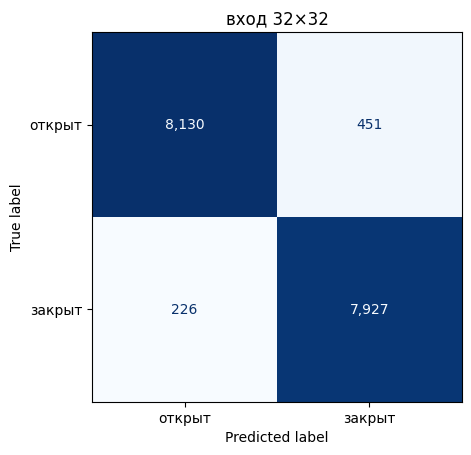


=== вход 64×64 ===
обучение: 1.5 мин   вход: 64×64

              precision    recall  f1-score   support

        open     0.9786    0.9772    0.9779      8581
      closed     0.9760    0.9776    0.9768      8153

    accuracy                         0.9774     16734
   macro avg     0.9773    0.9774    0.9773     16734
weighted avg     0.9774    0.9774    0.9774     16734

ROC-AUC: 0.9967


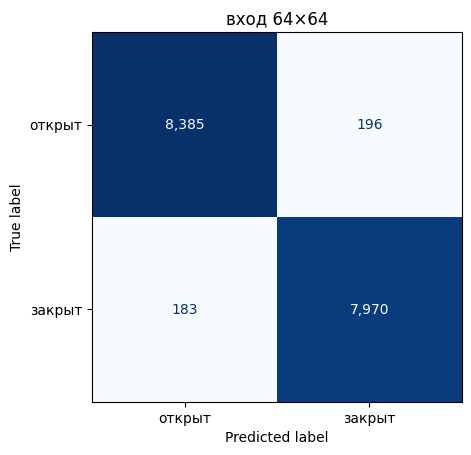


=== вход 96×96 ===
обучение: 1.9 мин   вход: 96×96

              precision    recall  f1-score   support

        open     0.9771    0.9760    0.9766      8581
      closed     0.9748    0.9760    0.9754      8153

    accuracy                         0.9760     16734
   macro avg     0.9759    0.9760    0.9760     16734
weighted avg     0.9760    0.9760    0.9760     16734

ROC-AUC: 0.9969


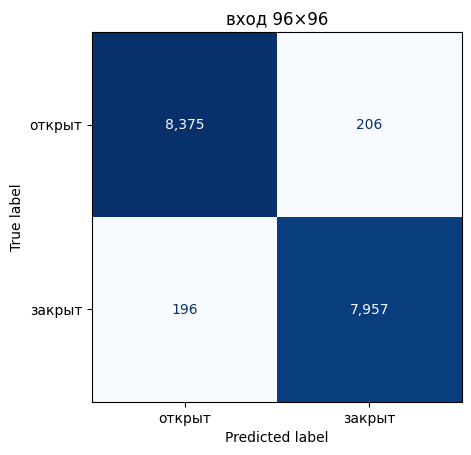


 вход  точность  минут
32×32    0.9595    1.4
64×64    0.9774    1.6
96×96    0.9760    2.1


In [41]:
rows = []
for img in (32, 64, 96):
    seed_all(42)
    model = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)
    w = model.conv1.weight.data.sum(1, keepdim=True)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.conv1.weight.data = w
    model.fc = nn.Linear(512, 1)

    t0 = time.time()
    _, acc = train_and_report(f"вход {img}×{img}", model, img=img, keep=False)
    rows.append({"вход": f"{img}×{img}", "точность": round(acc, 4),
                 "минут": round((time.time() - t0) / 60, 1)})
    print()

print(pd.DataFrame(rows).to_string(index=False))

## Выводы

**1. Слишком простая сеть почти не работает.**
Сеть из 2 слоев показала точность 0,4313 — это хуже, чем при постоянном ответе «открыт». Такой подход дал бы 0,5128, поскольку открытых кадров в тестовой выборке немного больше. ROC-AUC 0,551 также близок к случайному угадыванию.

При увеличении глубины до 4 слоев точность выросла до 0,9028, а до 6 слоев — до 0,9445. Это показывает, что для данной задачи сети нужна достаточная глубина, чтобы выделять полезные признаки изображения.

**2. Сама архитектура ResNet дает небольшой выигрыш.**
ResNet-18, обученная с нуля, показала 0,9569, а собственная сеть из 6 слоев — 0,9445. Разница составила всего 0,0124.

При этом ResNet-18 содержит около 11 миллионов параметров, а собственная сеть — около 135 тысяч. Следовательно, более сложная архитектура сама по себе дает небольшой прирост качества.

**3. Главный выигрыш дает предобучение.**
ResNet-18 с весами ImageNet показала 0,9774, а та же модель без предобучения — 0,9569. Разница составила 0,0205.

Это больше, чем прирост от других изменений в проведенных экспериментах. Следовательно, предобученная модель эффективно использует признаки, полученные при обучении на большом наборе изображений.

**4. Увеличивать модель дальше почти нет смысла.**
VGG-11, ResNet-18 и ResNet-34 показали 0,9718, 0,9774 и 0,9720 соответственно. Разница между ними составляет менее одного процента.

При этом VGG-11 содержит около 128 миллионов параметров, а ResNet-18 — около 11 миллионов. Более крупные модели не дают заметного улучшения, но требуют больше памяти и вычислений.

**5. DenseNet-121 показала лучший результат, но разница слишком мала.**
DenseNet-121 показала точность 0,9802 — самый высокий результат среди проверенных моделей.

Однако точность одной и той же модели между эпохами изменялась примерно на 0,0075. Разница между DenseNet-121 и предобученной ResNet-18 составляет всего 0,0028, то есть значительно меньше этого разброса.

Поэтому нельзя достоверно утверждать, что DenseNet-121 лучше. При этом время ее обучения составило 2,2 минуты против 1,5 минуты у ResNet-18.

## Аугментация

Полная аугментация показала лучший результат во всех трех проверках:

- на чистом тесте — 0,9774 против 0,9725 без аугментации;
- на зашумленных кадрах — 0,9613 против 0,6355;
- на затемненных кадрах — 0,9533 против 0,5967.

На чистых данных разница небольшая. На испорченных кадрах влияние аугментации значительно сильнее: без нее качество модели заметно снижается.

Отдельные виды аугментации влияют на разные типы искажений:

- **отражение** почти не повлияло на результат;
- **шум** значительно повысил устойчивость к зашумленным кадрам: 0,6355 → 0,9617;
- **гамма и яркость** улучшили работу на темных кадрах: 0,8422 → 0,9533.

Таким образом, модель становится устойчивее к тем искажениям, которые присутствовали во время обучения.

## Размер изображения

Лучший результат получен при размере **64×64** — 0,9774.

При **96×96** точность составила 0,9760, то есть улучшения не произошло, а время обучения увеличилось с 1,6 до 2,1 минуты.

При **32×32** точность снизилась до 0,9595. При таком разрешении теряется слишком много деталей изображения глаза.

Поэтому размер 64×64 является хорошим компромиссом: увеличение разрешения не улучшает результат, а уменьшение уже снижает качество.

## Количество эпох

Основные модели обучались в течение 3 эпох. Для проверки достаточности этого количества ResNet-18 была дополнительно обучена в течение 10 эпох.

Ошибка на обучающей выборке продолжала снижаться — с 0,1056 до 0,0267. При этом точность на новых людях почти не менялась и оставалась в диапазоне 0,9699–0,9774.

Это показывает, что после третьей эпохи модель продолжает лучше подстраиваться под обучающие данные, но качество на новых данных практически не растет.

Следовательно, трех эпох для данной задачи достаточно.

Также было установлено, что точность между эпохами может изменяться примерно на 0,0075. Поэтому различия между моделями, которые меньше этого значения, нельзя считать надежными.

## Разбор ошибок

Для анализа ошибок была выбрана лучшая модель и рассмотрены случаи ее неправильных предсказаний.

**Точность зависит от конкретного человека.**
Средняя точность составила 0,9802, однако для худшего испытуемого она снизилась до 0,9342, а для лучшего достигла 0,9972.

Это показывает, что общая метрика может скрывать случаи, когда на отдельных людях модель работает заметно хуже.

**Сильнее всего мешают очки и блики.**
Для кадров с очками точность составила 0,9716 против 0,9834 без очков. При сильном блике — 0,9620 против 0,9824.

Плохое освещение влияет значительно меньше: 0,9791 против 0,9820. Это может быть связано с тем, что изменение яркости уже использовалось при аугментации.

Блики представляют более сложную проблему, поскольку могут частично закрывать сам глаз, а подобное искажение в аугментации не использовалось.

**Часть ошибок, вероятно, связана с данными, а не с моделью.**

Все наиболее уверенные ошибки принадлежат одному испытуемому, s0036, и относятся к одному типу: кадр размечен как «открыт», модель отвечает «закрыт» с уверенностью выше 0,998.

Номера кадров образуют две группы. В первой испытуемый в очках — оправа пересекает глаз, и такого искажения в обучении не было. Во второй очков нет: вероятно, происходило моргание, не отражённое в разметке, либо тёмный макияж вдоль линии ресниц, который сеть принимает за сомкнутое веко.

Поля про макияж в датасете нет, поэтому последнее — наблюдение по кадрам, а не измерение.

## Итог

Для данной задачи в качестве основной модели была выбрана **предобученная ResNet-18**.

DenseNet-121 показала немного более высокую точность, однако разница оказалась меньше обычного разброса между эпохами. При этом DenseNet-121 требует больше времени на обучение.

VGG-11 и ResNet-34 также не дали заметного преимущества, несмотря на больший размер.

Главный вывод: **главную роль играет предобучение, а не размер модели или сложность архитектуры.**

Аугментация также имеет большое значение. На чистых кадрах она почти не влияет на результат, но значительно повышает устойчивость к шуму и плохому освещению.